In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device('cuda')

# include parent dir in python path
# sys.path.append('/media/carsen/ssd1/approxineuro/notebooks')
sys.path.append('/media/carsen/ssd1/github/oneshot')

In [23]:
from utils import data
mouse_id = 12
depth_separable = True
pool = True
clamp = True
use_30k = False # use all data recorded (>30k) or only 30k, performance will decrease if use only 30k.
data_path = '../data'

# change path to your own dm11 path
img_root = '/home/carsen/dm11_pachitariu/data/STIM/'
# weight_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights'
weight_path = '../weights/'

In [24]:
# load images
img = data.load_images(img_root, file=os.path.join(img_root, data.img_file_name[mouse_id]), crop=True)
nimg, Ly, Lx = img.shape
print('img: ', img.shape, img.min(), img.max(), img.dtype)

raw image shape:  (68032, 66, 264)
cropped image shape:  (68032, 66, 130)
image mean:  126.71216
image std:  61.42324
img:  (68032, 66, 130) -2.062935 2.088588 float32


In [25]:
# load neurons
fname = '%s_nat30k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id, fixtrain=use_30k)
n_stim, n_neurons = spks.shape
print('spks: ', spks.shape, spks.min(), spks.max())
print('spks_rep_all: ', len(spks_rep_all), spks_rep_all[0].shape)
print('istim_train: ', istim_train.shape, istim_train.min(), istim_train.max())
print('istim_test: ', istim_test.shape, istim_test.min(), istim_test.max())


loading activities from ../data/FX43_nat30k_2025_05_19.npz
spks:  (29500, 4180) -1.110223e-16 5.6614475
spks_rep_all:  500 (10, 4180)
istim_train:  (29500,) 532 30031
istim_test:  (500,) 32 531


In [26]:
# split train and validation set
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
print('itrain: ', itrain.shape, itrain.min(), itrain.max())
print('ival: ', ival.shape, ival.min(), ival.max())


splitting training and validation set...
there is currently no randomness in this function now, please make sure the istim_train is in random order!
itrain:  (26550,)
ival:  (2950,)
itrain:  (26550,) 1 29499
ival:  (2950,) 0 29490


In [27]:
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)


normalizing neural data...


In [28]:
from utils import metrics
test_fev = metrics.fev_nan(spks_rep_all)
print('FEV (test): ', np.mean(test_fev))

valid_idxes = np.where(test_fev > 0.15)[0]
print('valid_idxes: ', len(valid_idxes))

FEV (test):  0.14340354963175775
valid_idxes:  1681


In [29]:
# ineur = np.arange(0, n_neurons) #np.arange(0, n_neurons, 5)
ineur = np.where(test_fev > 0.1)[0] # use only neurons with FEV > 0.15
spks_train = torch.from_numpy(spks[itrain][:,ineur])
spks_val = torch.from_numpy(spks[ival][:,ineur]) 
spks_rep_all = [spks_rep_all[i][:,ineur] for i in range(len(spks_rep_all))]
print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())

img_train = torch.from_numpy(img[istim_train][itrain]).to(device).unsqueeze(1) # change :130 to 25:100 
img_val = torch.from_numpy(img[istim_train][ival]).to(device).unsqueeze(1)
img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)

print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

input_Ly, input_Lx = img_train.shape[-2:]

spks_train:  torch.Size([26550, 2341]) tensor(-8.1106e-16) tensor(30.9300)
spks_val:  torch.Size([2950, 2341]) tensor(0.) tensor(28.9629)
img_train:  torch.Size([26550, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')
img_val:  torch.Size([2950, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')
img_test:  torch.Size([500, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')


In [30]:
train_real_responses = torch.ones_like(spks_train)
val_real_responses = torch.ones_like(spks_val)
# set nans to zero
train_real_responses[torch.isnan(spks_train)] = 0
val_real_responses[torch.isnan(spks_val)] = 0
spks_train[torch.isnan(spks_train)] = 0
spks_val[torch.isnan(spks_val)] = 0

In [53]:
# build model
from utils import model_builder
nlayers = 3
nconv1 = 64
nconv2 = 64
model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable, input_Ly=input_Ly, input_Lx=input_Lx)
model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, ineuron=len(ineur))
# weight_path = './checkpoints/'
model_path = os.path.join(weight_path, 'fullmodel', data.mouse_names[mouse_id], model_name)
print('modelpath: ', model_path)
model = model.to(device)

input shape of readout:  (64, 33, 65)
model name:  FX43_051925_3layer_64_64_64_clamp_sensorium_depthsep_pool_nneurons_2341.pt
modelpath:  ../weights/fullmodel/FX43/FX43_051925_3layer_64_64_64_clamp_sensorium_depthsep_pool_nneurons_2341.pt


In [54]:
# train model
from utils import model_trainer
if not os.path.exists(model_path):
    best_state_dict = model_trainer.monkey_train(model, spks_train, train_real_responses, spks_val, val_real_responses, img_train, img_val, device=device)
    torch.save(best_state_dict, model_path)
    print('model saved', model_path)
model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

0.001
epoch 0, train_loss = 0.0087, val_loss = 0.0085, varexp_val = 0.0660, time 15.26s
epoch 1, train_loss = 0.0083, val_loss = 0.0084, varexp_val = 0.0839, time 29.73s
epoch 2, train_loss = 0.0082, val_loss = 0.0083, varexp_val = 0.0975, time 44.69s
epoch 3, train_loss = 0.0082, val_loss = 0.0083, varexp_val = 0.1048, time 59.96s
epoch 4, train_loss = 0.0081, val_loss = 0.0082, varexp_val = 0.1105, time 75.87s
epoch 5, train_loss = 0.0081, val_loss = 0.0082, varexp_val = 0.1141, time 91.37s
epoch 6, train_loss = 0.0081, val_loss = 0.0082, varexp_val = 0.1189, time 105.73s
epoch 7, train_loss = 0.0081, val_loss = 0.0082, varexp_val = 0.1203, time 120.38s
epoch 8, train_loss = 0.0080, val_loss = 0.0082, varexp_val = 0.1232, time 134.85s
epoch 9, train_loss = 0.0080, val_loss = 0.0082, varexp_val = 0.1251, time 148.83s
epoch 10, train_loss = 0.0080, val_loss = 0.0082, varexp_val = 0.1273, time 162.92s
epoch 11, train_loss = 0.0080, val_loss = 0.0082, varexp_val = 0.1272, time 176.97s
ep

In [33]:
# test model
from utils import model_trainer
test_pred = model_trainer.test_epoch(model, img_test)
print('test_pred: ', test_pred.shape, test_pred.min(), test_pred.max())

test_pred:  (500, 2341) 0.0035773516 6.547735


In [35]:
from utils import metrics
test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
print('FEVE (test): ', np.mean(test_feve))

threshold = 0.1
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

threshold = 0.1
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

threshold = 0.15
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')
# threshold = 0.01
# print(f'filtering neurons with FEV > {threshold}')
# valid_idxes = np.where((test_fev > threshold) & (test_fev < 0.15))[0]
# print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
# print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

print(f'filtering neurons with FEV > {threshold} and FEVE > 0')
valid_idxes = np.where((test_fev > threshold) & (test_feve > 0))[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[valid_idxes])}')

FEVE (test):  0.6482623122145325
filtering neurons with FEV > 0.1
valid neurons: 2341 / 2341
FEVE (test): 0.6482623122145325
filtering neurons with FEV > 0.1
valid neurons: 2341 / 2341
FEVE (test): 0.6482623122145325
filtering neurons with FEV > 0.15
valid neurons: 1681 / 2341
FEVE (test): 0.6681679617878192
filtering neurons with FEV > 0.15 and FEVE > 0
valid neurons: 1681 / 2341
FEVE (test): 0.6681679617878192


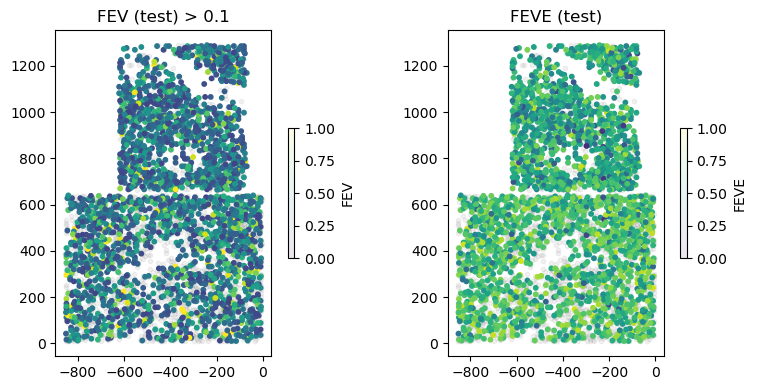

In [52]:
fig, ax = plt.subplots(1,2, figsize=(8, 4))
pix_res = [.5, .5]

valid_idxes = np.where(test_fev > 0.1)[0]
xpos_plot, ypos_plot  = xpos[valid_idxes]/pix_res[0], ypos[valid_idxes]/pix_res[1]
xpos_plot_all, ypos_plot_all = xpos/ pix_res[0], ypos/ pix_res[1]

ax[0].scatter(-ypos_plot_all, xpos_plot_all, c='gray', s=10, alpha=0.1)
ax[0].scatter(-ypos_plot, xpos_plot, c=test_fev[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=0.5)
ax[0].set_aspect('equal', adjustable='box')
# add colorbar
cbar = fig.colorbar(ax[0].collections[0], ax=ax[0], shrink=0.4)
cbar.set_label('FEV')
ax[0].set_title('FEV (test) > 0.1')

# valid_idxes = np.where(test_feve > 0.1)[0]

ax[1].scatter(-ypos_plot_all, xpos_plot_all, c='gray', s=10, alpha=0.1)
ax[1].scatter(-ypos_plot, xpos_plot, c=test_feve[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
ax[1].set_aspect('equal', adjustable='box')
# add colorbar
cbar = fig.colorbar(ax[1].collections[0], ax=ax[1], shrink=0.4)
cbar.set_label('FEVE')
ax[1].set_title('FEVE (test)')

plt.tight_layout()
plt.show()

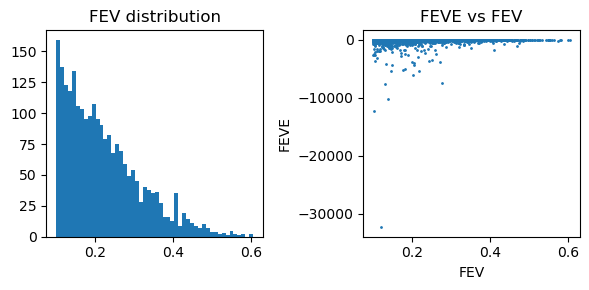

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
threshold = 0.01
valid_idxes = np.where(test_fev > threshold)[0]
ax[0].hist(test_fev, bins=50)
# ax[0].axvline(0.025, color='r')
ax[0].set_title('FEV distribution')
ax[1].scatter(test_fev[valid_idxes], test_feve[valid_idxes], s=1)
ax[1].set_title('FEVE vs FEV')
ax[1].set_xlabel('FEV')
ax[1].set_ylabel('FEVE')
plt.tight_layout()
#ax[1].set_ylim(0, 1)
plt.show()

In [ ]:
spks_rep_all[0].shape

(10, 2341)

# retinotopy

In [ ]:
from utils.model_utils import weight_bandwidth
x_pixel_ratio = 0.75
y_pixel_ratio = 0.5
Wx = model.readout.Wx.cpu().detach().numpy()
Wy = model.readout.Wy.cpu().detach().numpy()
# outer product of Wx and Wy
Wxy = np.einsum('icj,ick->ijk', Wy, Wx)
Wx = Wx.squeeze()
Wy = Wy.squeeze()
NN = Wx.shape[0]
bandwidth_Wx = np.zeros(NN)
bandwidth_Wy = np.zeros(NN)
centerpos_Wx = np.zeros(NN)
centerpos_Wy = np.zeros(NN)
for i in range(NN):
    bandwidth_Wx[i], centerpos_Wx[i] = weight_bandwidth(Wx[i, :], return_peak=True)
    bandwidth_Wy[i], centerpos_Wy[i] = weight_bandwidth(Wy[i, :], return_peak=True)

rf_size = bandwidth_Wx * bandwidth_Wy
rf_size = np.sqrt(rf_size* (270/264)*(65/66)) * 2 
print(f'average rf size: {np.mean(rf_size):.2f}')
xpos_model = np.argmax(Wx.squeeze(), axis=1) 
ypos_model = np.argmax(Wy.squeeze(), axis=1) 
xpos_visual = centerpos_Wx*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
ypos_visual = centerpos_Wy*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
# if mouse_id == 5: xpos_visual += (46*270/264) # xrange of mouse 6 is 46-176
xpos_plot = xpos / x_pixel_ratio
ypos_plot = ypos / y_pixel_ratio


average rf size: 48.67


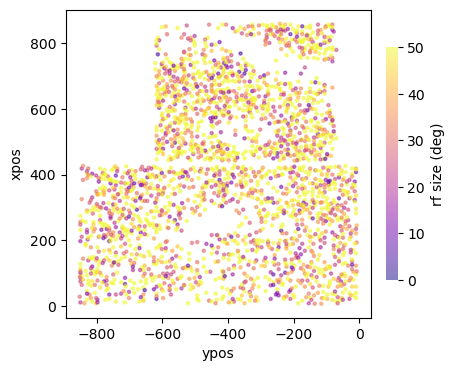

In [ ]:
valid_idxes = np.where(test_fev > 0.01)[0]

ineurons = valid_idxes
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
vmax = 50
sc = ax.scatter(-ypos_plot[ineurons], xpos_plot[ineurons], s=5, c=rf_size[ineurons], cmap='plasma', alpha=0.5, vmin=0, vmax=vmax)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('ypos')
ax.set_ylabel('xpos')
cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('rf size (deg)')
# plt.suptitle(f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}, FEV and FEVE matched neurons')

In [ ]:

Lx, Ly = Wx.shape[-1], Wy.shape[-1]
xmid, ymid = int(Lx/2), int(Ly/2)
x_xrange, y_xrange = np.arange(Lx), np.arange(Ly)

ineurons = np.arange(0, NN)
# Define a common x range for interpolation, e.g., based on the min and max of x_xrange and center positions
common_x = np.linspace(np.min(x_xrange - np.max(centerpos_Wx)), 
                    np.max(x_xrange - np.min(centerpos_Wx)), 
                    num=len(x_xrange))

# Container for interpolated Wx values
interp_Wx_values = []
from scipy.interpolate import interp1d
for i in ineurons:
    # Original x values for this neuron, shifted by its center position
    original_x = x_xrange - centerpos_Wx[i]
    # Interpolation function for the current neuron's Wx values
    interp_func = interp1d(original_x, Wx[i], kind='linear', bounds_error=False, fill_value=np.NaN)
    # Interpolate onto the common x range and store the result
    interp_Wx_values.append(interp_func(common_x))
    # plt.plot(original_x, Wx[i, 0, :], color='whitesmoke', alpha=1/255)

interp_Wx_values = np.array(interp_Wx_values)
common_x = common_x * (2*270/264)
mean_Wx = np.nanmean(interp_Wx_values[valid_idxes], axis=0)
std_Wx = np.nanstd(interp_Wx_values[valid_idxes], axis=0)
# Plot the mean Wx, now properly aligned and interpolated


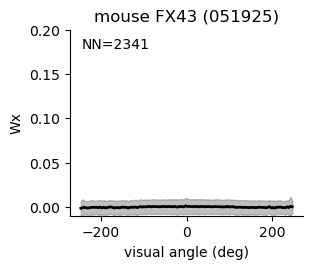

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.plot(common_x[5:-5], mean_Wx[5:-5], color='black', linewidth=2)
ax.fill_between(common_x[5:-5], mean_Wx[5:-5]-std_Wx[5:-5], mean_Wx[5:-5]+std_Wx[5:-5], color='gray', alpha=0.5)

ax.set_xlabel('visual angle (deg)')
ax.set_ylabel('Wx')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.text(0.1, 0.9, f'FEV > 0.8', transform=ax.transAxes)
ax.text(0.05, 0.9, f'NN={len(valid_idxes)}', transform=ax.transAxes)
# ax.set_xlim(-75, 75)
ax.set_ylim(-0.01, 0.2)
ax.set_aspect(0.8/ax.get_data_ratio(), adjustable='box')  
ax.set_title(f'mouse {data.mouse_names[mouse_id]} ({data.exp_date[mouse_id]})')
plt.show()

/tmp/ipykernel_16965/2678719054.py:5: RuntimeWarning: All-NaN slice encountered
  peak2 = np.nanmax(interp_Wx_values[:, xrange_peak2], axis=1)
/tmp/ipykernel_16965/2678719054.py:15: RuntimeWarning: Mean of empty slice
  mean_Wx = np.nanmean(interp_Wx_values[ineurons], axis=0)
/home/carsen/anaconda3/envs/torchenv/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


valid neurons: 0 / 2341


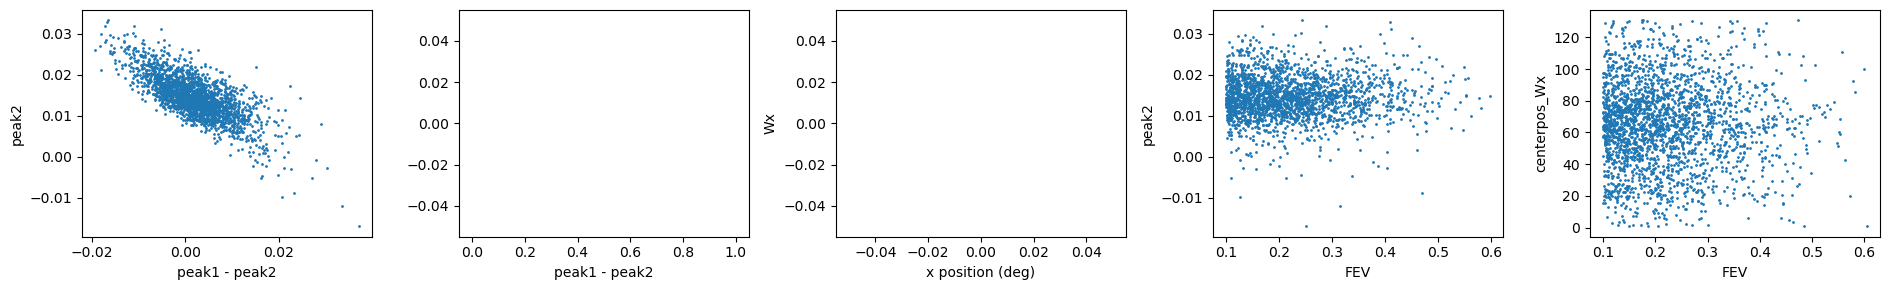

In [ ]:
NN, nxpos = interp_Wx_values.shape
xrange_peak1 = np.where((common_x > -50) & (common_x < 50))[0]
xrange_peak2 = np.where((common_x > -150) & (common_x < -50))[0]
peak1 = np.nanmax(interp_Wx_values[:, xrange_peak1], axis=1)
peak2 = np.nanmax(interp_Wx_values[:, xrange_peak2], axis=1)
peak_diff = peak1 - peak2
fig, ax = plt.subplots(1, 5, figsize=(19, 3))
ineurons = np.where(peak2>0.04)[0]
print(f'valid neurons: {len(ineurons)} / {len(peak2)}')
ax[0].scatter(peak_diff, peak2, s=1)
ax[0].set_xlabel('peak1 - peak2')
ax[0].set_ylabel('peak2')
ax[1].hist(peak_diff[ineurons], bins=50)
ax[1].set_xlabel('peak1 - peak2')
mean_Wx = np.nanmean(interp_Wx_values[ineurons], axis=0)
std_Wx = np.nanstd(interp_Wx_values[ineurons], axis=0)
ax[2].plot(common_x, mean_Wx, color='black')
ax[2].fill_between(common_x, mean_Wx-std_Wx, mean_Wx+std_Wx, color='gray', alpha=0.5)
ax[2].set_xlabel('x position (deg)')
ax[2].set_ylabel('Wx')
ax[3].scatter(test_fev, peak2, s=1)
ax[3].set_xlabel('FEV')
ax[3].set_ylabel('peak2')
ax[4].scatter(test_fev, centerpos_Wx, s=1)
ax[4].set_xlabel('FEV')
ax[4].set_ylabel('centerpos_Wx')
plt.tight_layout()
plt.show()

In [ ]:
ineurons = np.where(centerpos_Wx > 60)[0]

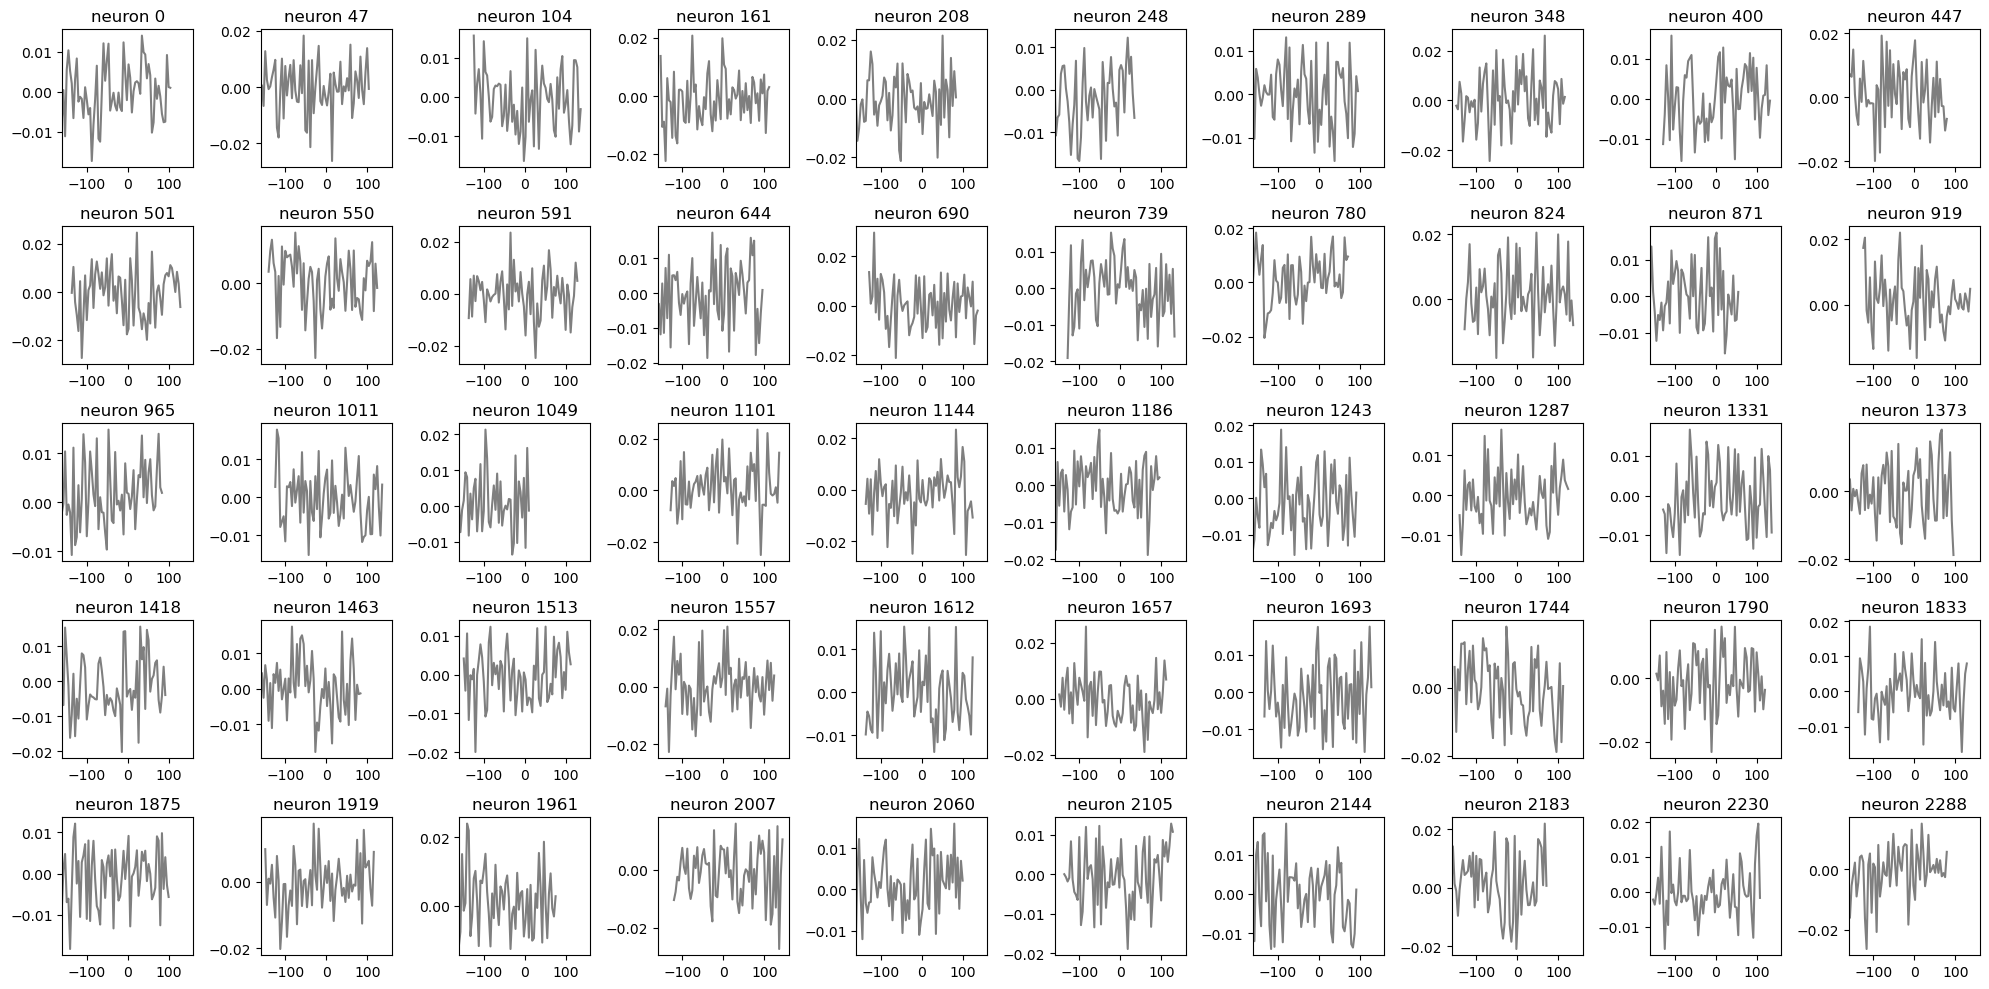

In [ ]:
fig, ax = plt.subplots(5, 10, figsize=(20, 10))
k = int(len(ineurons)/50)
for i in range(50):
    ax[i//10, i%10].plot(common_x, interp_Wx_values[ineurons[i*k]], color='black', alpha=0.5)
    ax[i//10, i%10].set_title(f'neuron {ineurons[i*k]}')
    ax[i//10, i%10].set_xlim(-160, 160)
plt.tight_layout()

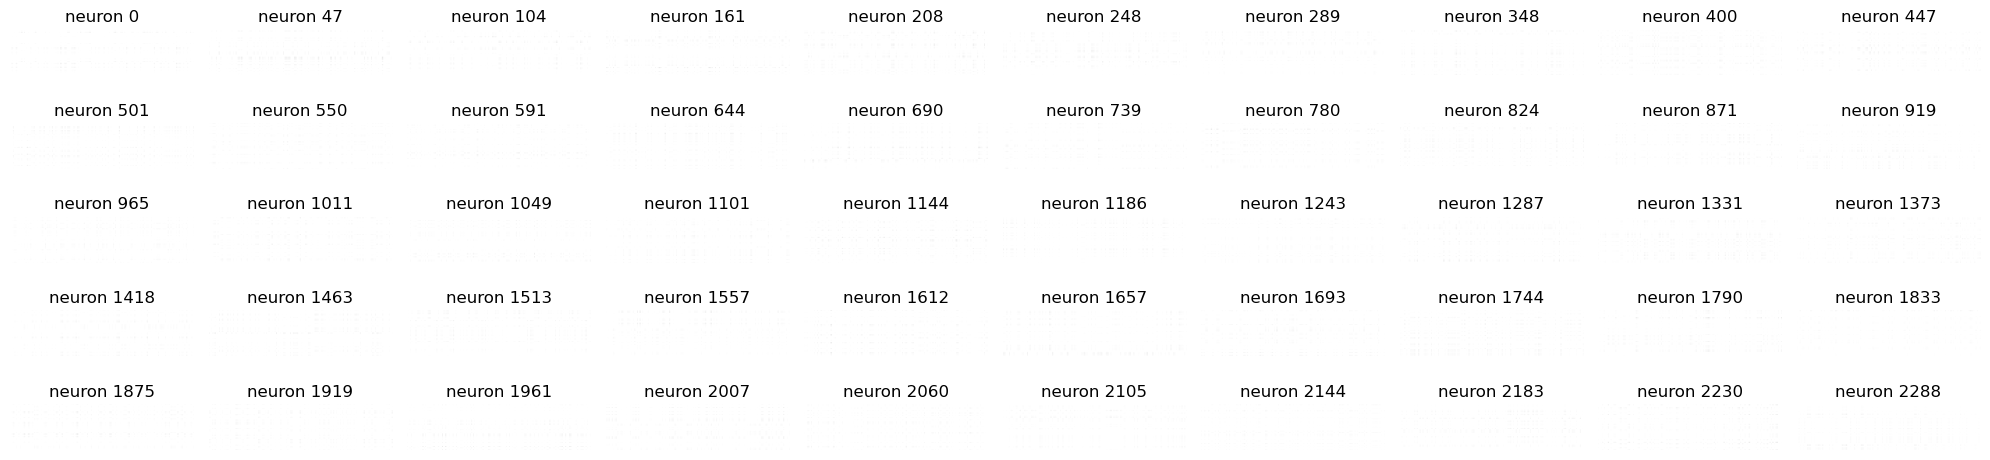

In [ ]:
fig, ax = plt.subplots(5, 10, figsize=(20, 5))
for i in range(50):
    ax[i//10, i%10].imshow(Wxy[ineurons[i*k]], cmap='gray_r', vmin=0, vmax=0.01)
    ax[i//10, i%10].set_title(f'neuron {ineurons[i*k]}')
    ax[i//10, i%10].axis('off')
plt.tight_layout()

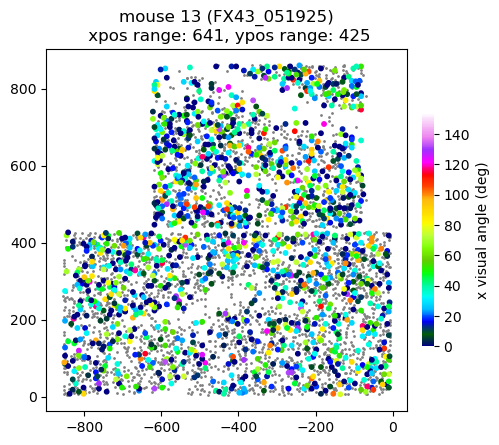

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(-ypos_plot, xpos_plot, s=1, c='gray')
sc = ax.scatter(-ypos_plot[ineurons], xpos_plot[ineurons], c=xpos_visual[ineurons], s=10, cmap='gist_ncar', vmin=0, vmax=(270 * (50/88)))
cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('x visual angle (deg)')
ax.set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos)-np.min(xpos)}, ypos range: {np.max(ypos)-np.min(ypos)}', loc='center')
ax.set_aspect('equal', adjustable='box')

ValueError: 'c' argument has 2341 elements, which is inconsistent with 'x' and 'y' with size 4180.

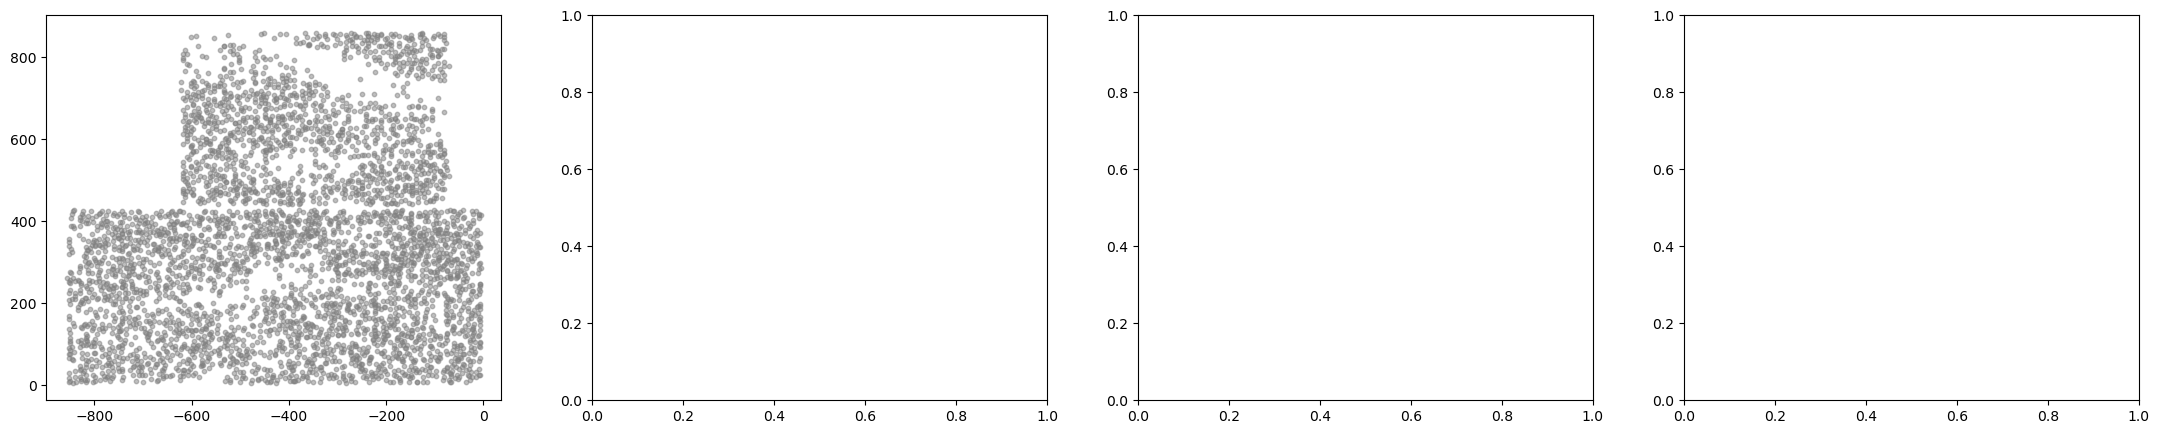

In [ ]:
valid_idxes = np.where(test_fev > 0.01)[0]

vmin_x = -135
vmax_x = 270 * (50/88)-135
vmin_y = -32.5
vmax_y = 65*(25/22)-32.5
fig, ax = plt.subplots(1, 4, figsize=(27, 5))
ax[0].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos_plot, xpos_plot, c=xpos_visual, s=10, cmap='gist_ncar', vmin=vmin_x, vmax=vmax_x, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('x visual angle (deg)')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[0].set_aspect('equal', adjustable='box')
# ax.set_axis_off()
# fig.savefig(f'./outputs/{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_xpos_visual.png', dpi=300, bbox_inches='tight')
# plt.close(fig)
ax[1].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[1].scatter(-ypos_plot, xpos_plot, c=ypos_visual, s=10, cmap='gist_ncar', vmin=vmin_y, vmax=vmax_y, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('y visual angle (deg)')
ax[1].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[1].set_aspect('equal', adjustable='box')

ax[2].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[2].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_fev[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[2], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEV')
ax[2].set_title(f'mouse {mouse_id+1} FEV', loc='center')
ax[2].set_aspect('equal', adjustable='box')

ax[3].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[3].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_feve[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[3], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE')
ax[3].set_title(f'mouse {mouse_id+1} FEVE', loc='center')
ax[3].set_aspect('equal', adjustable='box')



# visualize model

In [ ]:
model

Encoder(
  (core): Core(
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 16, kernel_size=(25, 25), stride=(1, 1), padding=(12, 12), bias=False)
        (norm): BatchNorm2d(16, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer1): Sequential(
        (ds_conv): Sequential(
          (in_depth_conv): Conv2d(16, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (spatial_conv): Conv2d(320, 320, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4), groups=320, bias=False)
          (out_depth_conv): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (norm): BatchNorm2d(320, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
      )
    )
  )
  (readout): Readout(
    (activation): ELU(alpha=1.0)
  )
  (bceloss

conv1_w:  (16, 25, 25) -0.5528213 0.50291634


Text(0.5, 0.98, 'FX42_012525\nconv1 weights')

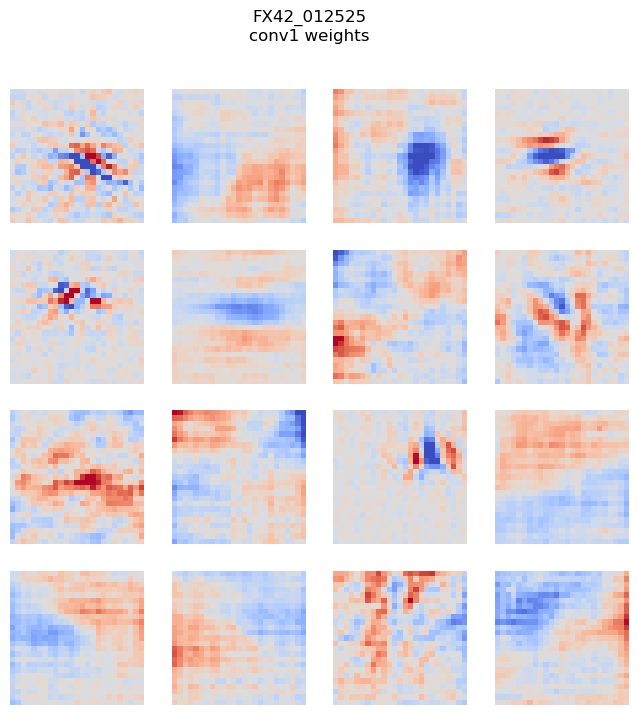

In [ ]:
conv1_w = model.core.features.layer0.conv.weight.detach().cpu().numpy().squeeze()
print('conv1_w: ', conv1_w.shape, conv1_w.min(), conv1_w.max())

fig, ax = plt.subplots(4, 4, figsize=(8, 8))
for i in range(16):
    ax[i//4, i%4].imshow(conv1_w[i], cmap='coolwarm', vmin=-0.2, vmax=0.2)
    ax[i//4, i%4].axis('off')
plt.suptitle(f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}\nconv1 weights')

In [ ]:
d

NameError: name 'd' is not defined

# multilayers result

In [ ]:
from utils import model_builder
# mouse_id = 0

feve_all = np.zeros((4, spks.shape[1]))
# for mouse_id in [6]:
# # load image
# img = data.load_images(img_root, file=os.path.join(img_root, data.img_file_name[mouse_id]))
# nimg, Ly, Lx = img.shape
# # load neurons
# fname = '%s_nat60k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
# spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id, fixtrain=use_30k)
# n_stim, n_neurons = spks.shape
# itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
# spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)
# img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)
# build model

weight_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel'

nlayers = 2
for nlayers in [1,2,3,4]:

    # build model
    from utils import model_builder
    nconv1 = 192
    nconv2 = 192
    model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable)
    model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='')
    # weight_path = './checkpoints/'
    model_path = os.path.join(weight_path, data.mouse_names[mouse_id], model_name)
    model = model.to(device)

    model.load_state_dict(torch.load(model_path))
    print('loaded model', model_path)

    from utils import model_trainer
    test_pred = model_trainer.test_epoch(model, img_test)
    print('test_pred: ', test_pred.shape, test_pred.min(), test_pred.max())

    from utils import metrics
    test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
    print('FEVE (test): ', np.mean(test_feve))

    threshold = 0.15
    print(f'filtering neurons with FEV > {threshold}')
    valid_idxes = np.where(test_fev > threshold)[0]
    print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
    print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

    threshold = 0.01
    print(f'filtering neurons with FEV > {threshold}')
    valid_idxes = np.where((test_fev > threshold) & (test_fev < 0.15))[0]
    print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
    print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

    feve_all[nlayers-1] = test_feve

input shape of readout:  (192, 33, 65)
model name:  FX41_012325_1layer_192_clamp_sensorium_depthsep_pool.pt


FileNotFoundError: [Errno 2] No such file or directory: '/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_012325_1layer_192_clamp_sensorium_depthsep_pool.pt'

In [ ]:
point1 = [-500, 0]
point2 = [-200, 650]
a = (point1[1] - point2[1]) / (point1[0] - point2[0])
b = point1[1] - a * point1[0]
imedial = np.where(xpos >= -a * ypos + b)[0]
ilateral = np.where(xpos < -a * ypos + b)[0]

ivalid = np.where((test_fev > 0.01)&(feve_all[1]>0.15))[0]

ineurons_medial = np.intersect1d(ivalid, imedial)
ineurons_lateral = np.intersect1d(ivalid, ilateral)

0.6464482140473069


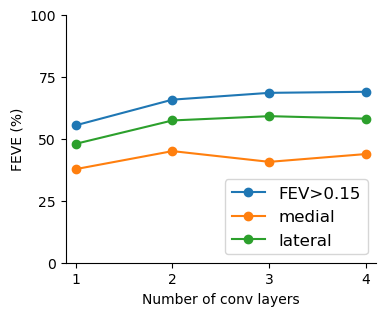

In [ ]:
ineurons = np.where(test_fev > 0.15)[0]
feve_our_model = feve_all[:, ineurons].mean(1)
# feve_lurz_model = lurz_feve_all
#  replace nans to 0
# feve_our_model = feve_our_model[:5]
# feve_lurz_model = feve_lurz_model[:5]
fig, ax = plt.subplots(1, 1, figsize=(4,4))
print(feve_our_model.mean(0))
from scipy.stats import sem
import seaborn as sns
cmap = sns.color_palette('rocket')
nmouse = 5
# ax.errorbar(np.arange(4), feve_our_model.mean(0), yerr=sem(feve_our_model, 0), c=cmap[1], capsize=5, label='our model')
# ax.errorbar(np.arange(4), feve_lurz_model .mean(0), yerr=sem(feve_lurz_model, 0), c='gray', capsize=5, label='sensorium model (2022)')
ax.plot(np.arange(4), feve_our_model, 'o-', label='FEV>0.15')
# ax.plot(np.arange(4), feve_lurz_model .mean(0), 'o-', c='gray', label='sensorium model (2022)')
    # ax.plot(np.arange(4), feve_lurz_model[i], c='gray', alpha=0.3)
# ax.legend(fontsize=12, loc='lower right')
# ax.text(1, 0.9, "FEV>0.15", transform=ax.transAxes, ha="right", color=cmap[1])
# ineurons = np.where(test_fev > 0.1)[0]
# feve_our_model = feve_all[:, ineurons].mean(1)
# ax.plot(np.arange(4), feve_our_model, 'o-', label='FEV>0.1')
# ineurons = np.where(test_fev > 0.01)[0]
# feve_our_model = feve_all[:, ineurons].mean(1)
# ax.plot(np.arange(4), feve_our_model, 'o-', label='FEV>0.01')

# ineurons = np.where((test_fev > 0.01))[0]
# feve_our_model = feve_all[:, ineurons].mean(1)
# ax.plot(np.arange(4), feve_our_model, 'o-', label='FEV>0.01')

feve_our_model = feve_all[:, ineurons_medial].mean(1)
ax.plot(np.arange(4), feve_our_model, 'o-', label='medial')
feve_our_model = feve_all[:, ineurons_lateral].mean(1)
ax.plot(np.arange(4), feve_our_model, 'o-', label='lateral')
# ax.text(1, 0.8, "sensorium model (2022)", transform=ax.transAxes, ha="right", color="gray")
# ax.text(1, 0.1, "N=6", transform=ax.transAxes, ha="right", fontsize=14)
ax.legend(fontsize=12, loc='lower right')
ax.set_xlabel('Number of conv layers')
ax.set_ylabel('FEVE (%)')
ax.set_ylim(0, 1)
ax.set_xlim(-0.1, 3.1)
ax.set_xticks([0, 1, 2, 3], [1, 2, 3, 4])
ax.set_yticks(np.arange(0, 1.1, 0.25), labels=[f'{i*100:.0f}' for i in np.arange(0, 1.1, 0.25)])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_aspect(0.8*np.diff(ax.get_xlim())/np.diff(ax.get_ylim()), adjustable='box')

# FEVE gain

(0.0, 1.0, 0.0, 1.0)

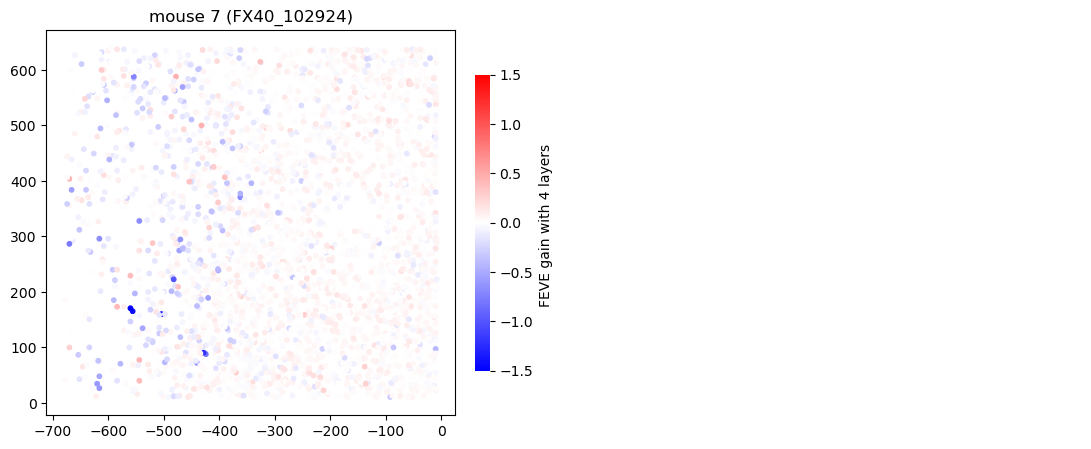

In [ ]:
valid_idxes = np.where((test_fev > 0.01)&(feve_all[1]>0))[0]
feve_diff = feve_all[3] - feve_all[1]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# ax[0].scatter(-ypos, xpos, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos[valid_idxes], xpos[valid_idxes], c=feve_diff[valid_idxes], s=10, cmap='bwr', vmin=-1.5, vmax=1.5)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE gain with 4 layers ')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})', loc='center')
ax[0].set_aspect('equal', adjustable='box')
ax[1].axis('off')

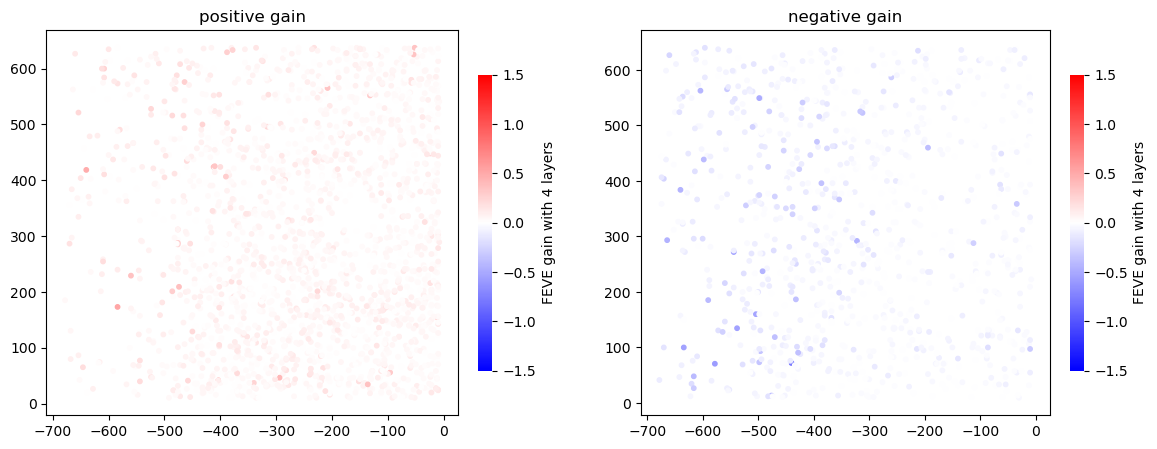

In [ ]:
valid_idxes = np.where((test_fev > 0.01)&(feve_all[1]>0))[0]
feve_diff = feve_all[2] - feve_all[1]
valid_idxes = np.intersect1d(valid_idxes, np.where(feve_diff > 0)[0])
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# ax[0].scatter(-ypos, xpos, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos[valid_idxes], xpos[valid_idxes], c=feve_diff[valid_idxes], s=10, cmap='bwr', vmin=-1.5, vmax=1.5)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE gain with 4 layers')
ax[0].set_title(f'positive gain', loc='center')
ax[0].set_aspect('equal', adjustable='box')
valid_idxes = np.where((test_fev > 0.01)&(feve_all[1]>0))[0]
valid_idxes = np.intersect1d(valid_idxes, np.where(feve_diff < 0)[0])
sc = ax[1].scatter(-ypos[valid_idxes], xpos[valid_idxes], c=feve_diff[valid_idxes], s=10, cmap='bwr', vmin=-1.5, vmax=1.5)
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE gain with 4 layers')
ax[1].set_title(f'negative gain', loc='center')
ax[1].set_aspect('equal', adjustable='box')


Text(0, 0.5, 'Density')

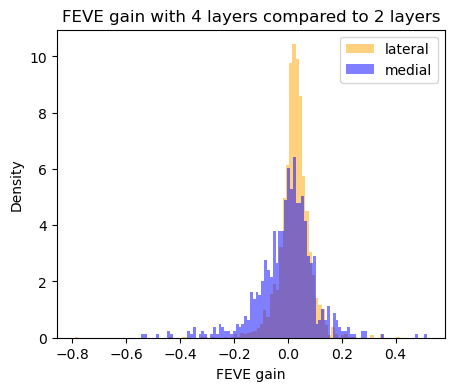

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(feve_diff[ineurons_lateral], bins=100, label='lateral', alpha=0.5, density=True, color='orange')
ax.hist(feve_diff[ineurons_medial], bins=100, label='medial', alpha=0.5, density=True, color='blue')
ax.legend()
ax.set_title('FEVE gain with 4 layers compared to 2 layers')
ax.set_xlabel('FEVE gain')
ax.set_ylabel('Density')


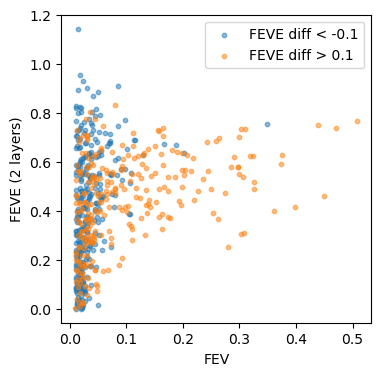

In [ ]:
idx = np.where(feve_diff < -0.1)[0]
valid_idxes = np.where((test_fev > 0.01)&(feve_all[1]>0))[0]
idx = np.intersect1d(idx, valid_idxes)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(test_fev[idx], feve_all[1][idx], s=10, alpha=0.5, label='FEVE diff < -0.1')
ax.set_xlabel('FEV')
ax.set_ylabel('FEVE (2 layers)')
idx = np.where(feve_diff > 0.1)[0]
idx = np.intersect1d(idx, valid_idxes)
ax.scatter(test_fev[idx], feve_all[1][idx], s=10, alpha=0.5, label='FEVE diff > 0.1')
ax.legend()

In [ ]:
# pooling area size

# build model
from utils import model_builder
nlayers = 2
nconv1 = 16
nconv2 = 320
model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable)
model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='')
# weight_path = './checkpoints/'
model_path = os.path.join(weight_path, 'fullmodel', f'{data.mouse_names[mouse_id]}', model_name)
# model = model.to(device)
model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

Wc = model.readout.Wc.detach().cpu().numpy().squeeze()
# # change model Wx and Wy
Wx = model.readout.Wx.detach().cpu().numpy()
Wy = model.readout.Wy.detach().cpu().numpy()
# outer product of Wx and Wy
Wxy = np.einsum('icj,ick->ijk', Wy, Wx)
print(Wxy.shape, Wc.shape)
print(Wc.shape, Wc.min(), Wc.max())

# rfsize from the Wxy
from utils.model_utils import weight_bandwidth
NN = Wxy.shape[0]
bandwidth_Wx = np.zeros(NN)
bandwidth_Wy = np.zeros(NN)
for i in range(NN):
    bandwidth_Wx[i] = weight_bandwidth(Wx[i, 0, :])
    bandwidth_Wy[i] = weight_bandwidth(Wy[i, 0, :])
rf_size = bandwidth_Wx * bandwidth_Wy
rf_size = np.sqrt(rf_size* (270/264)*(65/66)) * 2 
print(f'average rf size: {np.mean(rf_size):.2f}')

input shape of readout:  (320, 33, 65)
model name:  FX40_102924_2layer_16_320_clamp_sensorium_depthsep_pool.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX40/FX40_102924_2layer_16_320_clamp_sensorium_depthsep_pool.pt
(4261, 33, 65) (4261, 320)
(4261, 320) -0.57832915 0.6614029
average rf size: 25.93


(0.0, 1.0, 0.0, 1.0)

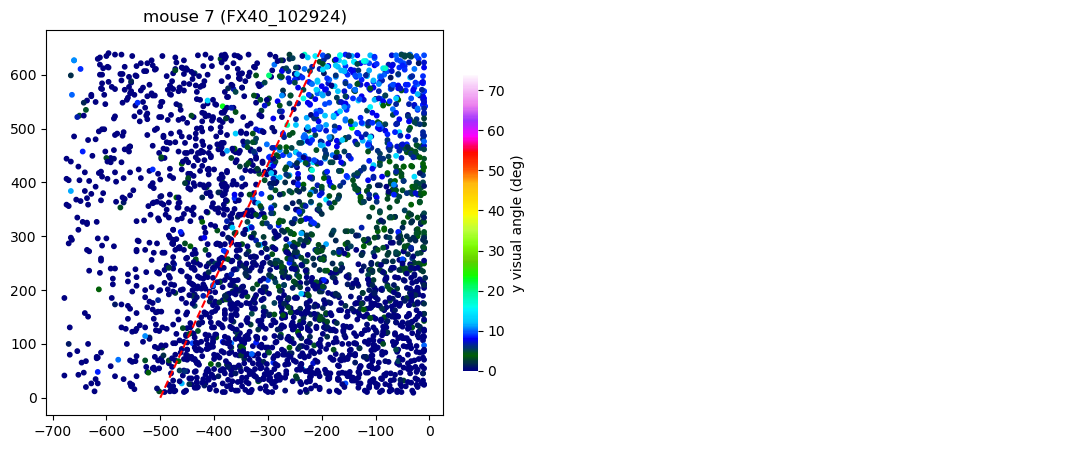

In [ ]:
point1 = [-500, 0]
point2 = [-200, 650]

valid_idxes = np.where((test_fev > 0.01)&(feve_all[1]>0))[0]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# ax[0].scatter(-ypos, xpos, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos[valid_idxes], xpos[valid_idxes], c=ypos_visual[valid_idxes], s=10, cmap='gist_ncar', vmin=0, vmax=65 * (25/22))
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('y visual angle (deg)')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})', loc='center')
ax[0].set_aspect('equal', adjustable='box')
ax[0].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--')
ax[1].axis('off')

-0.2954738679993669 2.50593674936947e-61


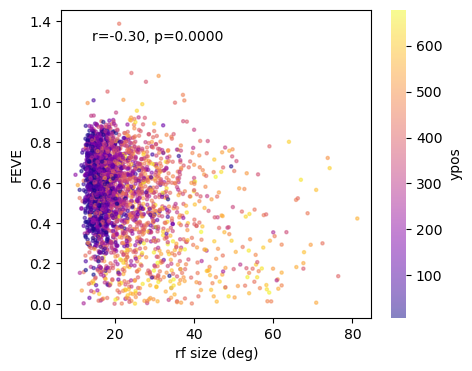

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sc = ax.scatter(rf_size[valid_idxes], feve_all[1][valid_idxes], s=5, c=ypos[valid_idxes], cmap='plasma', alpha=0.5)
ax.set_xlabel('rf size (deg)')
ax.set_ylabel('FEVE')
# signifiance test
from scipy.stats import pearsonr
r, p = pearsonr(rf_size[valid_idxes], feve_all[1][valid_idxes])
print(r, p)
ax.text(0.1, 0.9, f'r={r:.2f}, p={p:.4f}', transform=ax.transAxes)
# add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.outline.set_visible(False)
cbar.set_label('ypos')
# ax.set_xlim(0, 50)

Text(0, 0.5, 'count')

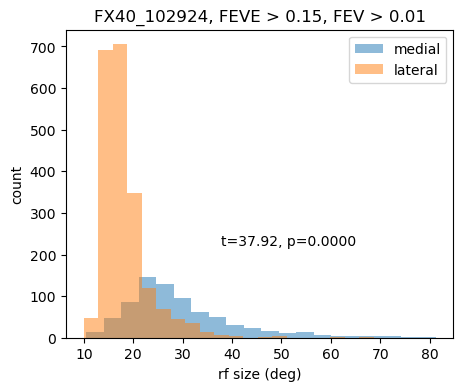

In [ ]:
# separate the neurons into two groups based on the line defined by point1 and point2
a = (point1[1] - point2[1]) / (point1[0] - point2[0])
b = point1[1] - a * point1[0]
imedial = np.where(xpos >= -a * ypos + b)[0]
ilateral = np.where(xpos < -a * ypos + b)[0]

ivalid = np.where((test_fev > 0.01)&(feve_all[1]>0.15))[0]

ineurons_medial = np.intersect1d(ivalid, imedial)
ineurons_lateral = np.intersect1d(ivalid, ilateral)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(rf_size[ineurons_medial], bins=20, alpha=0.5, label='medial')
ax.hist(rf_size[ineurons_lateral], bins=20, alpha=0.5, label='lateral')
ax.legend()
# signifiance test
from scipy.stats import ttest_ind
t, p = ttest_ind(rf_size[ineurons_medial], rf_size[ineurons_lateral])
ax.text(0.4, 0.3, f't={t:.2f}, p={p:.4f}', transform=ax.transAxes)
ax.set_title(f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}, FEVE > 0.15, FEV > 0.01')
ax.set_xlabel('rf size (deg)')
ax.set_ylabel('count')


-0.11488447093048594 0.0016364845513345424
[-21.68022943  30.96762972]


Text(0.5, 0.98, 'FX40_102924, medial neurons (FEV > 0.01, FEVE > 0.15)')

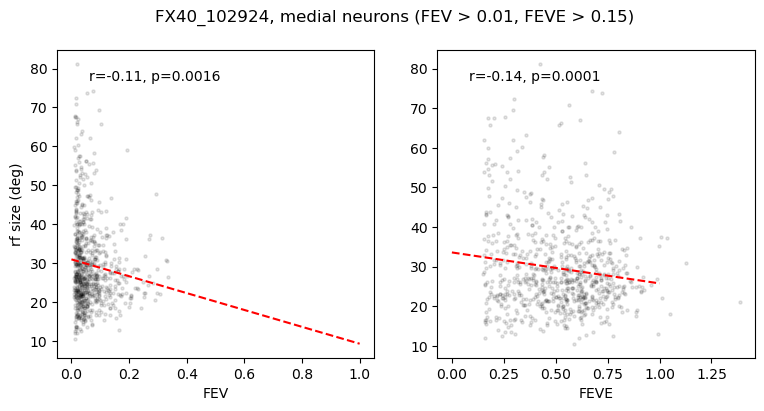

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ineurons = ineurons_medial.copy()
ax[0].scatter(test_fev[ineurons], rf_size[ineurons], s=5, c='k', alpha=0.1, label='lateral')
# signifiance test
from scipy.stats import pearsonr
r, p = pearsonr(test_fev[ineurons], rf_size[ineurons])
print(r, p)
# fit a line
from scipy.optimize import curve_fit
def func(x, a, b):
    return a*x + b
popt, pcov = curve_fit(func, test_fev[ineurons], rf_size[ineurons])
print(popt)
ax[0].plot(np.linspace(0, 1, 100), func(np.linspace(0, 1, 100), *popt), 'r--')
ax[0].text(0.1, 0.9, f'r={r:.2f}, p={p:.4f}', transform=ax[0].transAxes)
ax[0].set_xlabel('FEV')
ax[0].set_ylabel('rf size (deg)')

ax[1].scatter(feve_all[1][ineurons], rf_size[ineurons], s=5, c='k', alpha=0.1, label='lateral')
r, p = pearsonr(feve_all[1][ineurons], rf_size[ineurons])
popt, pcov = curve_fit(func, feve_all[1][ineurons], rf_size[ineurons])
ax[1].plot(np.linspace(0, 1, 100), func(np.linspace(0, 1, 100), *popt), 'r--')
ax[1].text(0.1, 0.9, f'r={r:.2f}, p={p:.4f}', transform=ax[1].transAxes)
ax[1].set_xlabel('FEVE')
plt.suptitle(f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}, medial neurons (FEV > 0.01, FEVE > 0.15)')

In [ ]:
# for each medial neuron, find a lateral neuron with the closest FEV and FEVE, and avoid duplicates
ineurons = ineurons_medial.copy()
nneurons = len(ineurons)
nneurons_lateral = len(ineurons_lateral)
dist = np.zeros((nneurons, nneurons_lateral))
for i in range(nneurons):
    for j in range(nneurons_lateral):
        dist[i, j] = np.sqrt((test_fev[ineurons[i]] - test_fev[ineurons_lateral[j]])**2 + (feve_all[1][ineurons[i]] - feve_all[1][ineurons_lateral[j]])**2)
ineurons_matched = np.zeros(nneurons, dtype=int)
for i in range(nneurons):
    j = np.argmin(dist[i])
    ineurons_matched[i] = j
    dist[:, j] = 100000000000

Text(0.5, 0.98, 'FX40_102924, medial neurons (FEV > 0.01, FEVE > 0.15)')

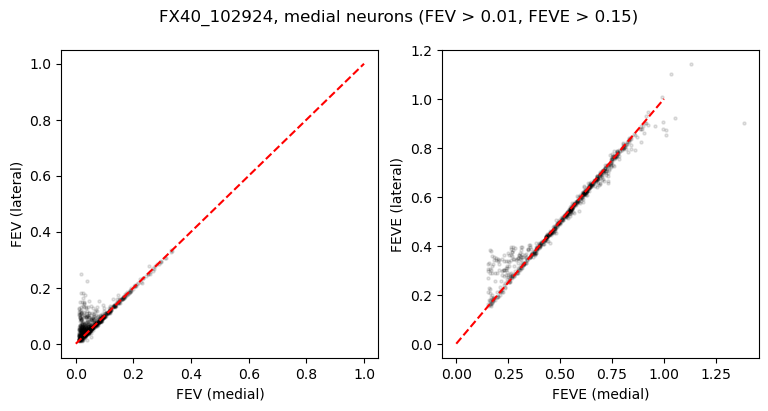

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(test_fev[ineurons], test_fev[ineurons_lateral[ineurons_matched]], s=5, c='k', alpha=0.1, label='lateral')
ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].set_xlabel('FEV (medial)')
ax[0].set_ylabel('FEV (lateral)')
ax[1].scatter(feve_all[1][ineurons], feve_all[1][ineurons_lateral[ineurons_matched]], s=5, c='k', alpha=0.1, label='lateral')
ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].set_xlabel('FEVE (medial)')
ax[1].set_ylabel('FEVE (lateral)')
plt.suptitle(f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}, medial neurons (FEV > 0.01, FEVE > 0.15)')

Text(0.5, 0, 'FEVE')

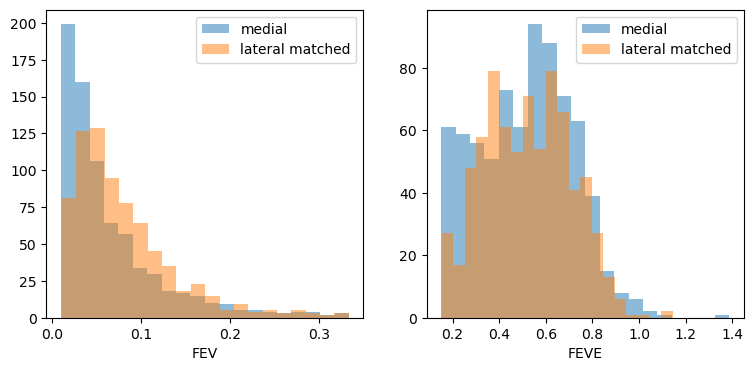

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].hist(test_fev[ineurons_medial], bins=20, alpha=0.5, label='medial')
ax[0].hist(test_fev[ineurons_lateral[ineurons_matched]], bins=20, alpha=0.5, label='lateral matched')
ax[0].legend()
ax[0].set_xlabel('FEV')
ax[1].hist(feve_all[1][ineurons_medial], bins=20, alpha=0.5, label='medial')
ax[1].hist(feve_all[1][ineurons_lateral[ineurons_matched]], bins=20, alpha=0.5, label='lateral matched')
ax[1].legend()
ax[1].set_xlabel('FEVE')

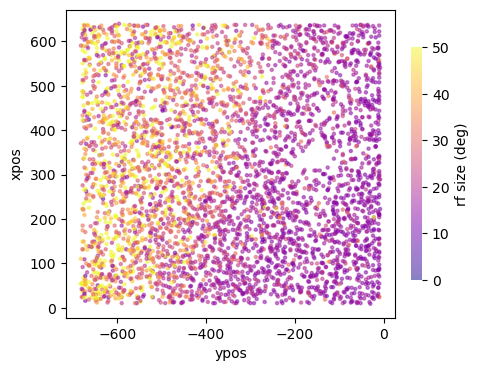

In [ ]:
ineurons = np.concatenate([ineurons_medial, ineurons_lateral[ineurons_matched]])
ineurons = np.arange(0, n_neurons)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
vmax = 50
sc = ax.scatter(-ypos[ineurons], xpos[ineurons], s=5, c=rf_size[ineurons], cmap='plasma', alpha=0.5, vmin=0, vmax=vmax)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('ypos')
ax.set_ylabel('xpos')
cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('rf size (deg)')
# plt.suptitle(f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}, FEV and FEVE matched neurons')

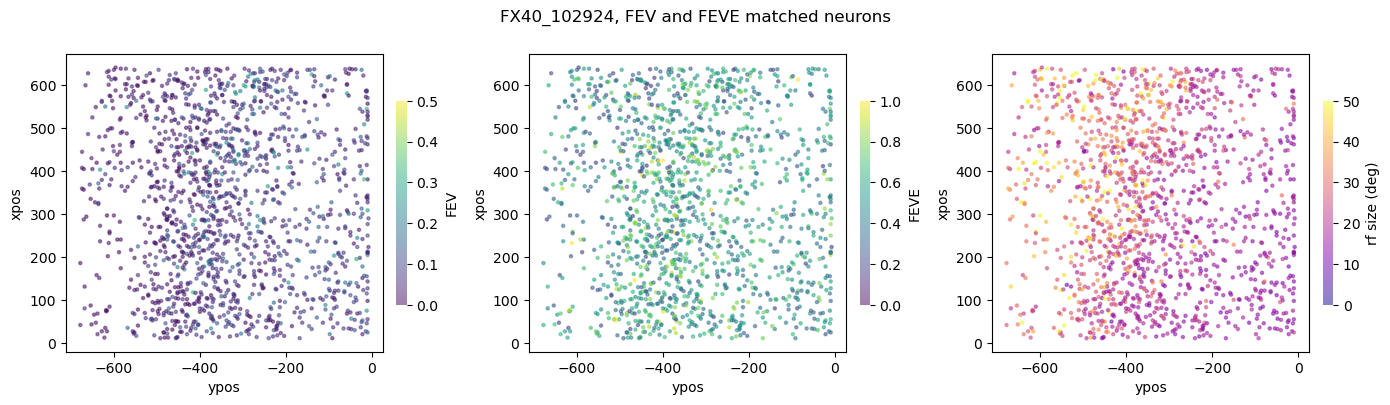

In [ ]:
ineurons = np.concatenate([ineurons_medial, ineurons_lateral[ineurons_matched]])
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
sc = ax[0].scatter(-ypos[ineurons], xpos[ineurons], s=5, c=test_fev[ineurons], cmap='viridis', alpha=0.5, vmin=0, vmax=0.5)
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlabel('ypos')
ax[0].set_ylabel('xpos')
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEV')
sc = ax[1].scatter(-ypos[ineurons], xpos[ineurons], s=5, c=feve_all[1][ineurons], cmap='viridis', alpha=0.5, vmin=0, vmax=1)
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlabel('ypos')
ax[1].set_ylabel('xpos')
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE')
vmax = 50
sc = ax[2].scatter(-ypos[ineurons], xpos[ineurons], s=5, c=rf_size[ineurons], cmap='plasma', alpha=0.5, vmin=0, vmax=vmax)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_xlabel('ypos')
ax[2].set_ylabel('xpos')
cbar = fig.colorbar(sc, ax=ax[2], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('rf size (deg)')
plt.suptitle(f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}, FEV and FEVE matched neurons')
plt.tight_layout()

Text(0.5, 1.0, 'matched neurons')

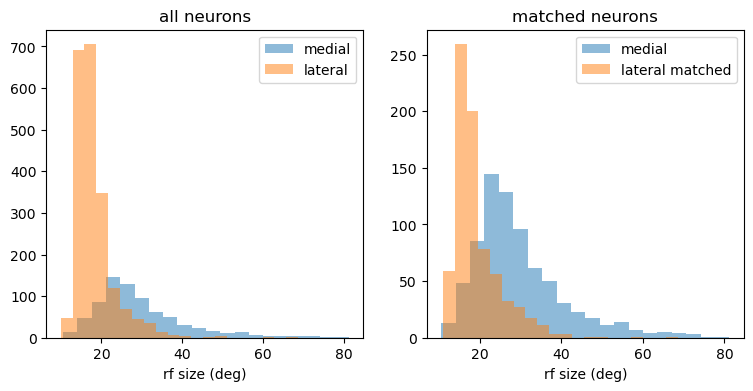

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].hist(rf_size[ineurons_medial], bins=20, alpha=0.5, label='medial')
ax[0].hist(rf_size[ineurons_lateral], bins=20, alpha=0.5, label='lateral')
ax[0].legend()
ax[0].set_xlabel('rf size (deg)')
ax[0].set_title(f'all neurons')
ax[1].hist(rf_size[ineurons_medial], bins=20, alpha=0.5, label='medial')
ax[1].hist(rf_size[ineurons_lateral[ineurons_matched]], bins=20, alpha=0.5, label='lateral matched')
ax[1].legend()
ax[1].set_xlabel('rf size (deg)')
ax[1].set_title(f'matched neurons')

In [ ]:
NN = Wx.shape[0]
bandwidth_Wx = np.zeros(NN)
bandwidth_Wy = np.zeros(NN)
centerpos_Wx = np.zeros(NN)
centerpos_Wy = np.zeros(NN)
for i in range(NN):
    bandwidth_Wx[i], centerpos_Wx[i] = weight_bandwidth(Wx[i, 0, :], return_peak=True)
    bandwidth_Wy[i], centerpos_Wy[i] = weight_bandwidth(Wy[i, 0, :], return_peak=True)

Lx, Ly = Wx.shape[-1], Wy.shape[-1]
xmid, ymid = int(Lx/2), int(Ly/2)
x_xrange, y_xrange = np.arange(Lx), np.arange(Ly)

ineurons = np.arange(0, NN)
# Define a common x range for interpolation, e.g., based on the min and max of x_xrange and center positions
common_x = np.linspace(np.min(x_xrange - np.max(centerpos_Wx)), 
                    np.max(x_xrange - np.min(centerpos_Wx)), 
                    num=len(x_xrange))

# Container for interpolated Wx values
interp_Wx_values = []

from scipy.interpolate import interp1d
for i in ineurons:
    # Original x values for this neuron, shifted by its center position
    original_x = x_xrange - centerpos_Wx[i]
    # Interpolation function for the current neuron's Wx values
    interp_func = interp1d(original_x, Wx[i, 0, :], kind='linear', bounds_error=False, fill_value=np.NaN)
    # Interpolate onto the common x range and store the result
    interp_Wx_values.append(interp_func(common_x))
    # plt.plot(original_x, Wx[i, 0, :], color='whitesmoke', alpha=1/255)
interp_Wx_values = np.array(interp_Wx_values)

/tmp/ipykernel_20529/3081185665.py:4: RuntimeWarning: Mean of empty slice
  mean_Wx = np.nanmean(interp_Wx_values[ineurons_medial], axis=0)
/tmp/ipykernel_20529/3081185665.py:17: RuntimeWarning: Mean of empty slice
  mean_Wx = np.nanmean(interp_Wx_values[ineurons_lateral[ineurons_matched]], axis=0)


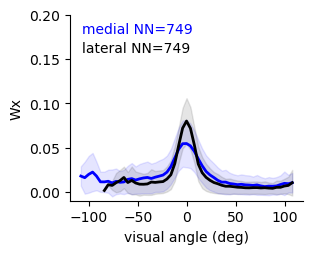

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))

common_x = common_x * (2*270/264)
mean_Wx = np.nanmean(interp_Wx_values[ineurons_medial], axis=0)
std_Wx = np.nanstd(interp_Wx_values[ineurons_medial], axis=0)
# Plot the mean Wx, now properly aligned and interpolated
ax.plot(common_x[5:-5], mean_Wx[5:-5], color='blue', linewidth=2)
ax.fill_between(common_x[5:-5], mean_Wx[5:-5]-std_Wx[5:-5], mean_Wx[5:-5]+std_Wx[5:-5], color='blue', alpha=0.1)

ax.set_xlabel('visual angle (deg)')
ax.set_ylabel('Wx')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.text(0.1, 0.9, f'FEV > 0.8', transform=ax.transAxes)
ax.text(0.05, 0.9, f'medial NN={len(ineurons_medial)}', transform=ax.transAxes, color='blue')

mean_Wx = np.nanmean(interp_Wx_values[ineurons_lateral[ineurons_matched]], axis=0)
std_Wx = np.nanstd(interp_Wx_values[ineurons_lateral[ineurons_matched]], axis=0)
# Plot the mean Wx, now properly aligned and interpolated
ax.plot(common_x[5:-5], mean_Wx[5:-5], color='black', linewidth=2)
ax.fill_between(common_x[5:-5], mean_Wx[5:-5]-std_Wx[5:-5], mean_Wx[5:-5]+std_Wx[5:-5], color='black', alpha=0.1)
ax.text(0.05, 0.8, f'lateral NN={len(ineurons_lateral[ineurons_matched])}', transform=ax.transAxes, color='black')
# ax.set_xlim(-75, 75)
ax.set_ylim(-0.01, 0.2)
ax.set_aspect(0.8/ax.get_data_ratio(), adjustable='box')  
plt.show()

In [ ]:
common_x = np.linspace(np.min(y_xrange - np.max(centerpos_Wy)), 
                       np.max(y_xrange - np.min(centerpos_Wy)), 
                       num=len(y_xrange))

# Container for interpolated Wx values
interp_Wy_values = []

for i in ineurons:
    # Original x values for this neuron, shifted by its center position
    original_x = y_xrange - centerpos_Wy[i]
    # Interpolation function for the current neuron's Wx values
    interp_func = interp1d(original_x, Wy[i, 0, :], kind='linear', bounds_error=False, fill_value=np.NaN)
    # Interpolate onto the common x range and store the result
    interp_Wy_values.append(interp_func(common_x))
    # plt.plot(original_x, Wy[i, 0, :], color='gray', alpha=0.1)

interp_Wy_values = np.array(interp_Wy_values)

/tmp/ipykernel_20529/4783747.py:4: RuntimeWarning: Mean of empty slice
  mean_Wx = np.nanmean(interp_Wy_values[ineurons_medial], axis=0)
/tmp/ipykernel_20529/4783747.py:17: RuntimeWarning: Mean of empty slice
  mean_Wx = np.nanmean(interp_Wy_values[ineurons_lateral[ineurons_matched]], axis=0)


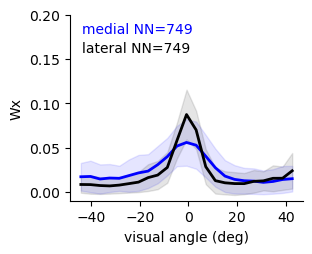

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))

common_x = common_x * (2*270/264)
mean_Wx = np.nanmean(interp_Wy_values[ineurons_medial], axis=0)
std_Wx = np.nanstd(interp_Wy_values[ineurons_medial], axis=0)
# Plot the mean Wx, now properly aligned and interpolated
ax.plot(common_x[5:-5], mean_Wx[5:-5], color='blue', linewidth=2)
ax.fill_between(common_x[5:-5], mean_Wx[5:-5]-std_Wx[5:-5], mean_Wx[5:-5]+std_Wx[5:-5], color='blue', alpha=0.1)

ax.set_xlabel('visual angle (deg)')
ax.set_ylabel('Wx')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.text(0.1, 0.9, f'FEV > 0.8', transform=ax.transAxes)
ax.text(0.05, 0.9, f'medial NN={len(ineurons_medial)}', transform=ax.transAxes, color='blue')

mean_Wx = np.nanmean(interp_Wy_values[ineurons_lateral[ineurons_matched]], axis=0)
std_Wx = np.nanstd(interp_Wy_values[ineurons_lateral[ineurons_matched]], axis=0)
# Plot the mean Wx, now properly aligned and interpolated
ax.plot(common_x[5:-5], mean_Wx[5:-5], color='black', linewidth=2)
ax.fill_between(common_x[5:-5], mean_Wx[5:-5]-std_Wx[5:-5], mean_Wx[5:-5]+std_Wx[5:-5], color='black', alpha=0.1)
ax.text(0.05, 0.8, f'lateral NN={len(ineurons_lateral[ineurons_matched])}', transform=ax.transAxes, color='black')
# ax.set_xlim(-75, 75)
ax.set_ylim(-0.01, 0.2)
ax.set_aspect(0.8/ax.get_data_ratio(), adjustable='box')  
plt.show()

Text(0.5, 0.98, 'medial neurons')

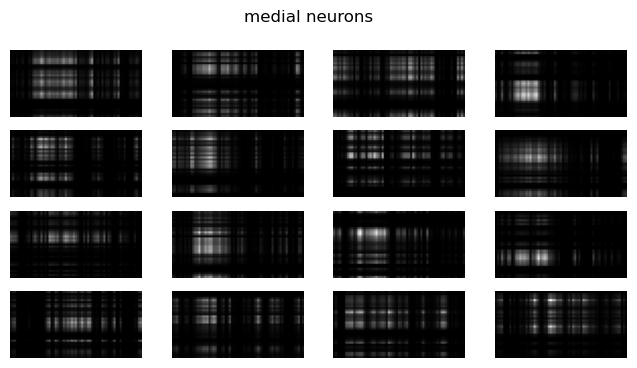

In [ ]:
Wxy = np.einsum('icj,ick->ijk', Wy, Wx)
Wxy.shape

# plot 16 wxy filters random

fig, ax = plt.subplots(4, 4, figsize=(8, 4))
ineurons = np.random.choice(np.arange(0, len(ineurons_medial)), 16, replace=False)
for i in range(16):
    ax[i//4, i%4].imshow(Wxy[ineurons_medial[ineurons[i]]], cmap='gray', vmin=0, vmax=0.01)
    ax[i//4, i%4].axis('off')
plt.suptitle('medial neurons')

Text(0.5, 0.98, 'lateral neurons')

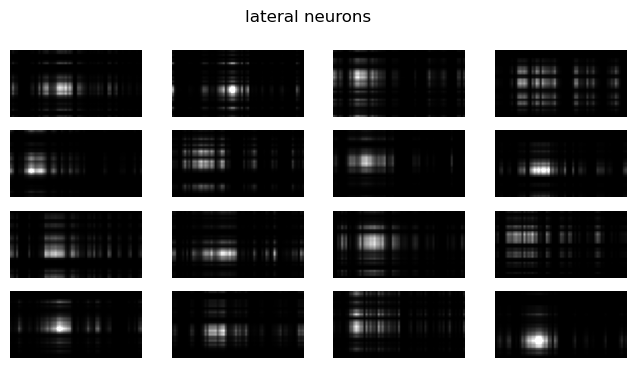

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(8, 4))
ineurons = np.random.choice(np.arange(0, len(ineurons_matched)), 16, replace=False)
for i in range(16):
    ax[i//4, i%4].imshow(Wxy[ineurons_lateral[ineurons_matched[ineurons[i]]]], cmap='gray', vmin=0, vmax=0.01)
    ax[i//4, i%4].axis('off')
plt.suptitle('lateral neurons')